In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from cbonds_api_test import CBondsAPI

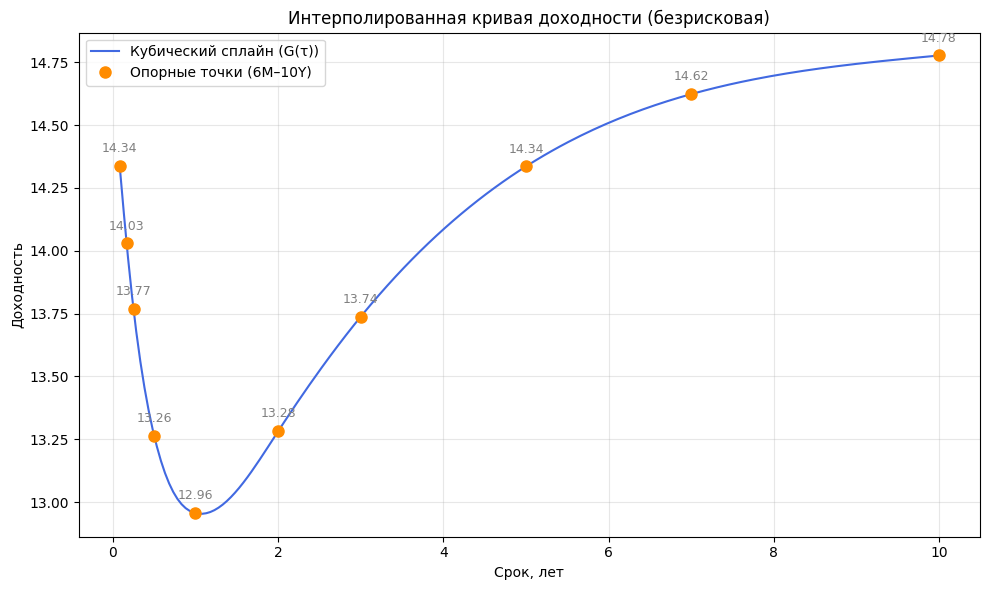

In [ ]:

api = CBondsAPI()

# --- Часть 1: получение данных и сплайн (как раньше) ---
tenors = ["1M", "2M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y"]
grid = {t: float(api.get_yield_curve(t, limit=1)[0]["value"]) for t in tenors}


def tenor_to_years(t: str) -> float:
    if t.endswith("M"):
        return float(t[:-1]) / 12.0
    elif t.endswith("Y"):
        return float(t[:-1])
    else:
        raise ValueError(f"Неизвестный формат срока: {t}")

points = sorted([(tenor_to_years(t), v) for t, v in grid.items()])
x = np.array([p[0] for p in points])
y = np.array([p[1] for p in points])

G = CubicSpline(x, y, bc_type='natural')

# --- Часть 2: график ---
# Точки для плавной линии
tau_fine = np.linspace(x[0], x[-1], 200)
y_fine = G(tau_fine)

plt.figure(figsize=(10, 6))
plt.plot(tau_fine, y_fine, '-', label='Кубический сплайн (G(τ))', color='royalblue')
plt.plot(x, y, 'o', label='Опорные точки (1M–10Y)', color='darkorange', markersize=8)

# Дополнительно можно подписать сроки у точек
for xi, yi in zip(x, y):
    plt.annotate(f'{yi:.2f}', (xi, yi), textcoords="offset points", xytext=(0,10),
                 ha='center', fontsize=9, color='grey')

plt.xlabel('Срок, лет')
plt.ylabel('Доходность')
plt.title('Интерполированная кривая доходности (безрисковая)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()